# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [19]:
import pandas as pd
import seaborn as sns
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 1. Importa el csv "temps.csv"

In [3]:
df = pd.read_csv("data/temps.csv")
df

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41
...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,41,50,47,47
344,2016,12,28,Wed,42,47,45.3,48,41,49,44,58
345,2016,12,29,Thurs,47,48,45.3,48,43,50,45,65
346,2016,12,30,Fri,48,48,45.4,57,44,46,44,42


### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            348 non-null    int64  
 1   month           348 non-null    int64  
 2   day             348 non-null    int64  
 3   week            348 non-null    object 
 4   temp_2          348 non-null    int64  
 5   temp_1          348 non-null    int64  
 6   average         348 non-null    float64
 7   actual          348 non-null    int64  
 8   forecast_noaa   348 non-null    int64  
 9   forecast_acc    348 non-null    int64  
 10  forecast_under  348 non-null    int64  
 11  friend          348 non-null    int64  
dtypes: float64(1), int64(10), object(1)
memory usage: 32.8+ KB


In [5]:
df.describe()

,year,month,day,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,57.238506,62.373563,59.772989,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,10.605746,10.549381,10.705256,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,41.000000,46.000000,44.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,48.000000,53.000000,50.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,56.000000,61.000000,58.000000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,66.000000,72.000000,69.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,77.000000,82.000000,79.000000,95.000000


In [6]:
df["week"].value_counts()

week
Tues     52
Sat      50
Fri      50
Sun      49
Mon      49
Wed      49
Thurs    49
Name: count, dtype: int64

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["num_sf"] = le.fit_transform(df["week"])
df

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,num_sf
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29,0
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61,2
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56,3
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53,1
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,41,50,47,47,5
344,2016,12,28,Wed,42,47,45.3,48,41,49,44,58,6
345,2016,12,29,Thurs,47,48,45.3,48,43,50,45,65,4
346,2016,12,30,Fri,48,48,45.4,57,44,46,44,42,0


In [10]:
week = {
"Mon" : 1, 
"Tues" : 2, 
"Wed" : 3, 
"Thurs" : 4, 
"Fri" : 5, 
"Sat" : 1, 
"Sun" : 1, 
}

df["num_dias"] = df["week"].replace(week)

df

C:\Users\Administrador\AppData\Local\Temp\ipykernel_10080\3501030999.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["num_dias"] = df["week"].replace(week)


,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,num_sf,num_dias
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29,0,5
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61,2,1
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56,3,1
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53,1,1
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,41,50,47,47,5,2
344,2016,12,28,Wed,42,47,45.3,48,41,49,44,58,6,3
345,2016,12,29,Thurs,47,48,45.3,48,43,50,45,65,4,4
346,2016,12,30,Fri,48,48,45.4,57,44,46,44,42,0,5


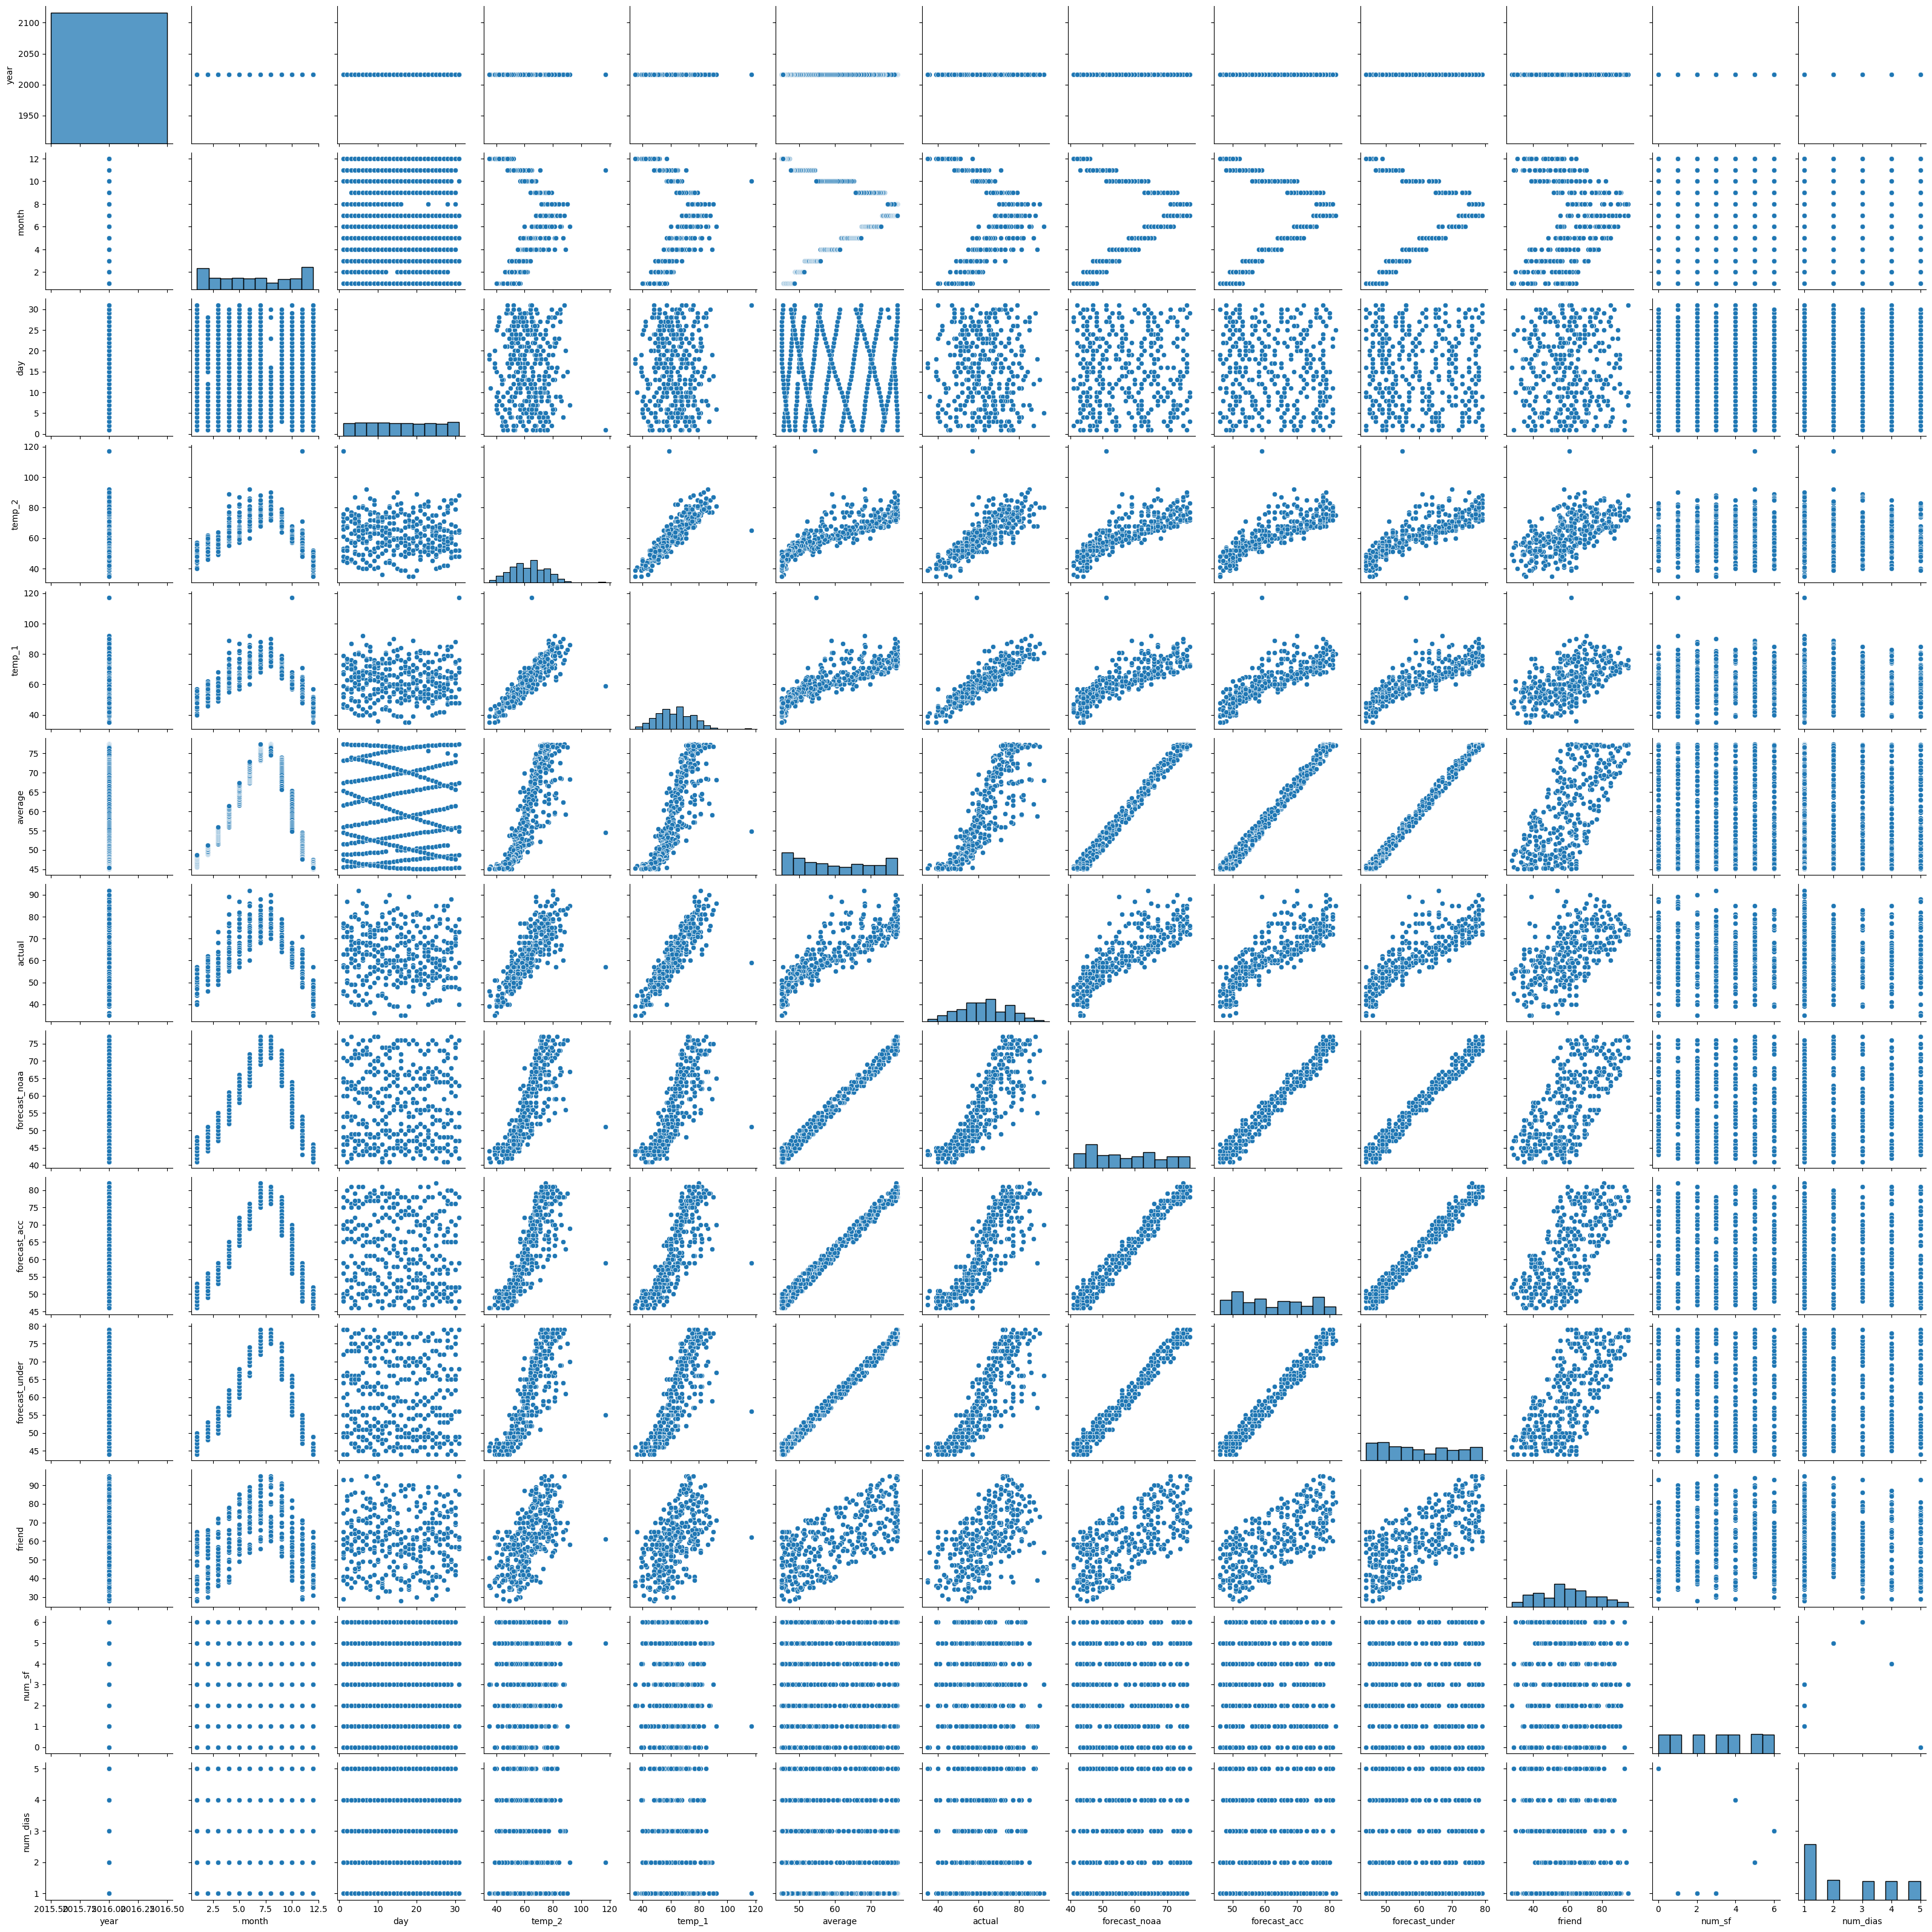

In [11]:
sns.pairplot(df)

<Axes: ylabel='temp_1'>

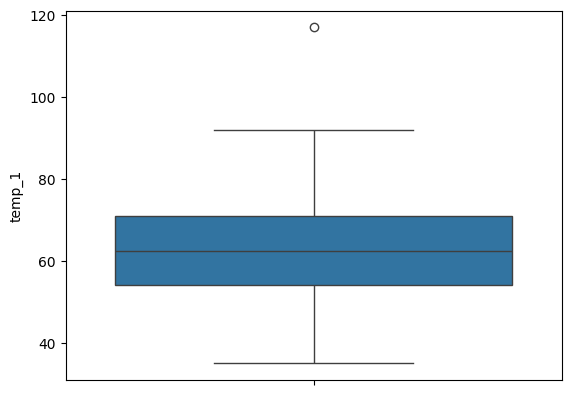

In [28]:
sns.boxplot(df["temp_1"])

<Axes: ylabel='temp_2'>

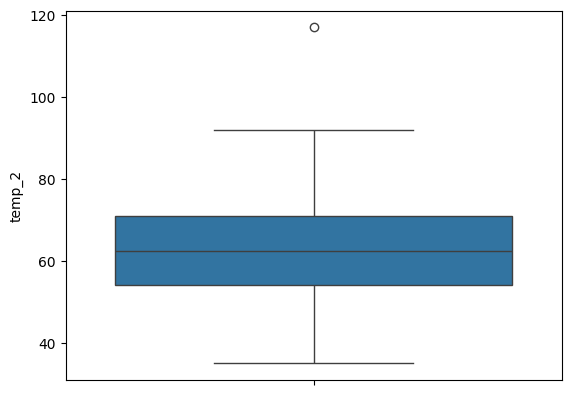

In [29]:
sns.boxplot(df["temp_2"])

<Axes: >

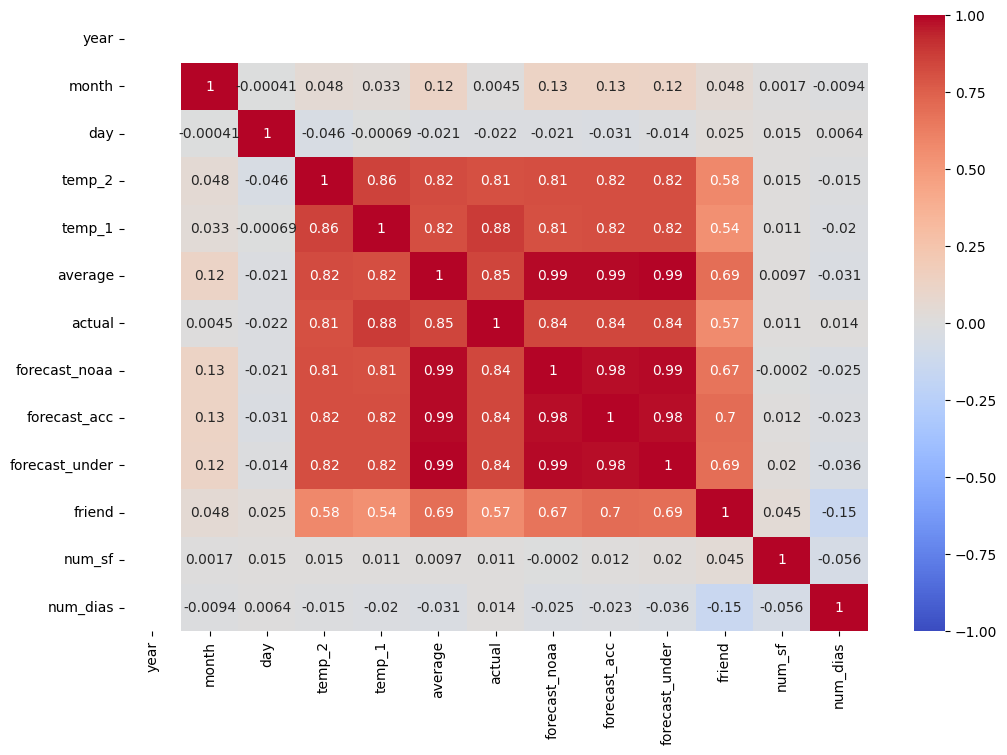

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1)

### 3. Selecciona variables y divide en train y test

In [32]:
X = df[["temp_2", "temp_1", "average", "friend", "forecast_noaa"]]
y = df["actual"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(278, 5)
(278,)
(70, 5)
(70,)


### 4. Entrena el modelo


In [33]:
dtr = DecisionTreeRegressor()     
dtr.fit(X_train, y_train)          
pred = dtr.predict(X_test)

### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

In [34]:
print("MAE: ", mean_absolute_error(y_test, pred))
print("RMSE: ", root_mean_squared_error(y_test, pred))
print("MAPE: ", mean_absolute_percentage_error(y_test, pred))
print("R2: ", r2_score(y_test, pred))

MAE:  5.171428571428572
RMSE:  6.572670690061994
MAPE:  0.08067274712917351
R2:  0.6951331919992627


In [35]:
dtr.score(X_test, y_test)

0.6951331919992627

### 6. Representa el árbol de decisión

[Text(0.4863261279396728, 0.9705882352941176, 'x[1] <= 62.5\nsquared_error = 137.169\nsamples = 278\nvalue = 62.147'),
 Text(0.25995334867075665, 0.9117647058823529, 'x[2] <= 49.25\nsquared_error = 51.487\nsamples = 137\nvalue = 52.905'),
 Text(0.37313973830521474, 0.9411764705882353, 'True  '),
 Text(0.09336656441717792, 0.8529411764705882, 'x[1] <= 45.5\nsquared_error = 29.209\nsamples = 62\nvalue = 47.016'),
 Text(0.041922290388548056, 0.7941176470588235, 'x[1] <= 41.5\nsquared_error = 16.966\nsamples = 21\nvalue = 41.714'),
 Text(0.012269938650306749, 0.7352941176470589, 'x[2] <= 45.15\nsquared_error = 12.512\nsamples = 11\nvalue = 39.818'),
 Text(0.0081799591002045, 0.6764705882352942, 'squared_error = 0.0\nsamples = 1\nvalue = 46.0'),
 Text(0.016359918200409, 0.6764705882352942, 'x[0] <= 40.5\nsquared_error = 9.56\nsamples = 10\nvalue = 39.2'),
 Text(0.0081799591002045, 0.6176470588235294, 'x[3] <= 37.0\nsquared_error = 3.36\nsamples = 5\nvalue = 36.8'),
 Text(0.00408997955010225

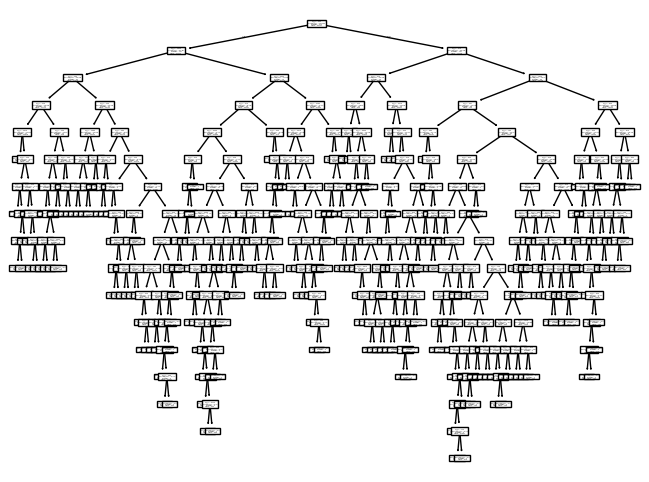

In [36]:
plt.figure(figsize=(8, 6))
plot_tree(dtr)

In [38]:
dtr_2 =DecisionTreeRegressor(max_depth=3)
dtr_2.fit(X_train, y_train)
pred = dtr_2.predict(X_test)

print("MAE: ", mean_absolute_error(y_test, pred))
print("RMSE: ", root_mean_squared_error(y_test, pred))
print("MAPE: ", mean_absolute_percentage_error(y_test, pred))
print("R2: ", r2_score(y_test, pred))

MAE:  4.254308906350133
RMSE:  5.427601353380941
MAPE:  0.06491876934915675
R2:  0.7921058441287924


[Text(0.5, 0.875, 'x[1] <= 62.5\nsquared_error = 137.169\nsamples = 278\nvalue = 62.147'),
 Text(0.25, 0.625, 'x[2] <= 49.25\nsquared_error = 51.487\nsamples = 137\nvalue = 52.905'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[1] <= 45.5\nsquared_error = 29.209\nsamples = 62\nvalue = 47.016'),
 Text(0.0625, 0.125, 'squared_error = 16.966\nsamples = 21\nvalue = 41.714'),
 Text(0.1875, 0.125, 'squared_error = 13.709\nsamples = 41\nvalue = 49.732'),
 Text(0.375, 0.375, 'x[2] <= 55.55\nsquared_error = 17.535\nsamples = 75\nvalue = 57.773'),
 Text(0.3125, 0.125, 'squared_error = 8.108\nsamples = 46\nvalue = 55.391'),
 Text(0.4375, 0.125, 'squared_error = 9.213\nsamples = 29\nvalue = 61.552'),
 Text(0.75, 0.625, 'x[1] <= 67.5\nsquared_error = 56.778\nsamples = 141\nvalue = 71.128'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[3] <= 61.0\nsquared_error = 20.766\nsamples = 46\nvalue = 64.87'),
 Text(0.5625, 0.125, 'squared_error = 18.15\nsamples = 20\nvalue = 62.5'),
 Text(0

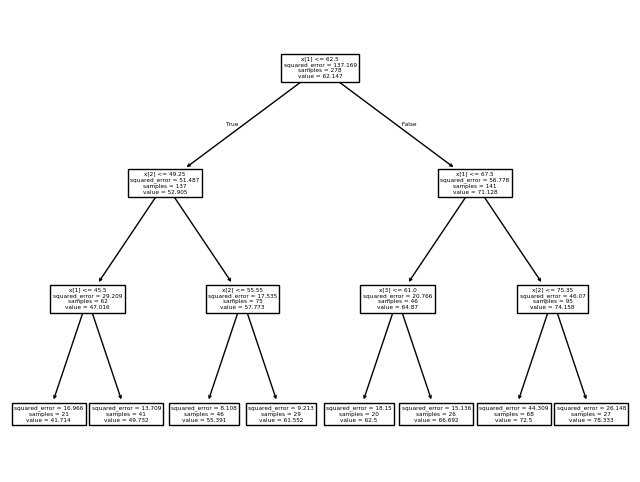

In [39]:
plt.figure(figsize=(15, ))
plot_tree(dtr_2)

### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [46]:
dtr_3 = DecisionTreeRegressor()

parametros = {"max_depth": [2, 3, 4, 5, 6, 7, 8, 9],
              "min_samples_leaf": [15, 20, 25]}

dtr_gs = GridSearchCV(
    estimator=dtr_3,
    param_grid=parametros,
    cv=10,
    scoring='neg_mean_absolute_error',
    verbose=3
)

dtr_gs.fit(X_train, y_train)

print(dtr_gs.best_estimator_)
print(dtr_gs.best_score_)
print(dtr_gs.best_params_)

Fitting 10 folds for each of 24 candidates, totalling 240 fits
[CV 1/10] END max_depth=2, min_samples_leaf=15;, score=-4.880 total time=   0.0s
[CV 2/10] END max_depth=2, min_samples_leaf=15;, score=-4.524 total time=   0.0s
[CV 3/10] END max_depth=2, min_samples_leaf=15;, score=-4.665 total time=   0.0s
[CV 4/10] END max_depth=2, min_samples_leaf=15;, score=-4.359 total time=   0.0s
[CV 5/10] END max_depth=2, min_samples_leaf=15;, score=-4.760 total time=   0.0s
[CV 6/10] END max_depth=2, min_samples_leaf=15;, score=-5.080 total time=   0.0s
[CV 7/10] END max_depth=2, min_samples_leaf=15;, score=-4.142 total time=   0.0s
[CV 8/10] END max_depth=2, min_samples_leaf=15;, score=-5.012 total time=   0.0s
[CV 9/10] END max_depth=2, min_samples_leaf=15;, score=-4.820 total time=   0.0s
[CV 10/10] END max_depth=2, min_samples_leaf=15;, score=-4.671 total time=   0.0s
[CV 1/10] END max_depth=2, min_samples_leaf=20;, score=-4.880 total time=   0.0s
[CV 2/10] END max_depth=2, min_samples_leaf=2

In [47]:
print(dtr_gs.best_estimator_)
print(dtr_gs.best_params_)
print(dtr_gs.best_score_)

DecisionTreeRegressor(max_depth=4, min_samples_leaf=15)
{'max_depth': 4, 'min_samples_leaf': 15}
-4.0439602913456545


### 8. Vuelve a evaluar tu modelo

### 9. Vuelve a representar su árbol

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [49]:
modelo_final = DecisionTreeRegressor(max_depth=4, min_samples_leaf=15)
modelo_final.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### 11. Obten el `feature_importances` de cada variable en el último modelo

In [50]:
modelo_final.feature_importances_

array([0.        , 0.19709631, 0.79435237, 0.00855132, 0.        ])

<Axes: >

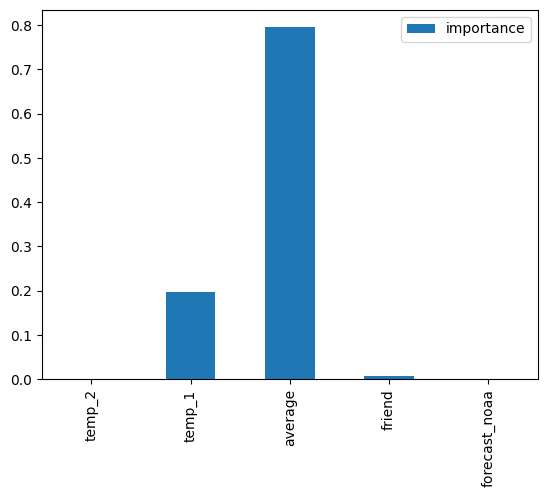

In [52]:
pd.DataFrame({"importance": modelo_final.feature_importances_}, index= X.columns).plot(kind="bar")

In [54]:
pred_modelo_final = modelo_final.predict([[45, 45, 45-6, 43, 47]])
pred_modelo_final

c:\Users\Administrador\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([46.40909091])

In [55]:
pred_modelo_final = modelo_final.predict([[0, 45, 45-6, 43, 0]])
pred_modelo_final

c:\Users\Administrador\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([46.40909091])

### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC. ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [56]:
df["target_c"] = np.where(df["actual"] > 59, 1, 0)

In [57]:
df["target_c"].value_counts(normalize=True)

target_c
1    0.586207
0    0.413793
Name: proportion, dtype: float64

In [58]:
X = df[["temp_1", "average"]]
y = df["target_c"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(278, 2)
(278,)
(70, 2)
(70,)


In [65]:
modelo = DecisionTreeClassifier()

parametros = {"max_depth": [2, 3, 4, 5, 6, 7, 8, 9],
              "min_samples_leaf": [15, 20, 25]}

modelo_gs = GridSearchCV(modelo, parametros, cv=10, scoring='accuracy', verbose=3)

modelo_gs.fit(X_train, y_train)

Fitting 10 folds for each of 24 candidates, totalling 240 fits
[CV 1/10] END .max_depth=2, min_samples_leaf=15;, score=0.929 total time=   0.0s
[CV 2/10] END .max_depth=2, min_samples_leaf=15;, score=0.821 total time=   0.0s
[CV 3/10] END .max_depth=2, min_samples_leaf=15;, score=0.857 total time=   0.0s
[CV 4/10] END .max_depth=2, min_samples_leaf=15;, score=0.893 total time=   0.0s
[CV 5/10] END .max_depth=2, min_samples_leaf=15;, score=0.964 total time=   0.0s
[CV 6/10] END .max_depth=2, min_samples_leaf=15;, score=1.000 total time=   0.0s
[CV 7/10] END .max_depth=2, min_samples_leaf=15;, score=0.857 total time=   0.0s
[CV 8/10] END .max_depth=2, min_samples_leaf=15;, score=0.821 total time=   0.0s
[CV 9/10] END .max_depth=2, min_samples_leaf=15;, score=0.926 total time=   0.0s
[CV 10/10] END max_depth=2, min_samples_leaf=15;, score=0.963 total time=   0.0s
[CV 1/10] END .max_depth=2, min_samples_leaf=20;, score=0.929 total time=   0.0s
[CV 2/10] END .max_depth=2, min_samples_leaf=2

,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [2, 3, ...], 'min_samples_leaf': [15, 20, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [64]:
print(modelo_gs.best_estimator_)
print(modelo_gs.best_params_)
print(modelo_gs.best_score_)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=20)
{'max_depth': 2, 'min_samples_leaf': 20}
-0.08968253968253967


In [67]:
modelo_final = modelo_gs.best_estimator_
modelo_final.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


<Axes: >

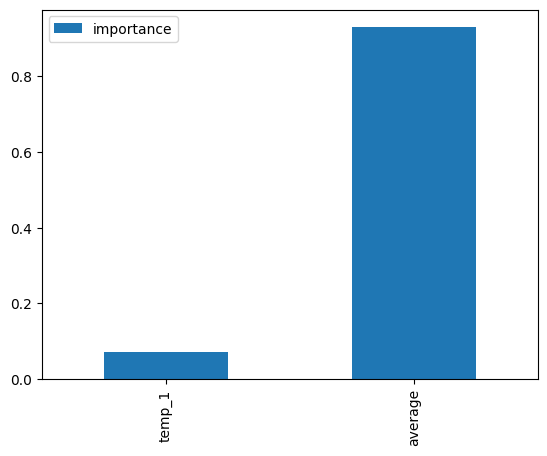

In [68]:
pd.DataFrame({"importance": modelo_final.feature_importances_}, index=X.columns).plot(kind="bar")